/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


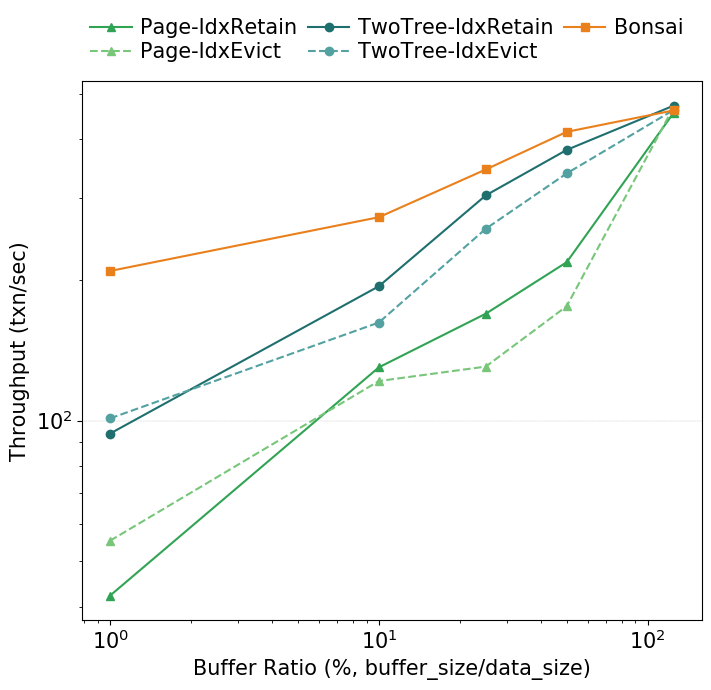

In [2]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)
bonsai_c = "#ea801c"
# page_retain_c = "#2066a8" 
# page_evict_c = "#3594cc"

page_retain_c = "#31a354" 
page_evict_c = "#78c679"

tt_retain_c = "#1f6f6f"
tt_evict_c = "#54a1a1" 
bonsai_line = "s"
page_line = "^"
tt_line = "o"

txtsize=10
ticksize=8

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
idxs = ["g_total_buf_sz", "read_perc_","g_total_buf_sz"]
datadir = "../../output/"
# exp_page = "debug_exp_point_10g_page_fanout250"
exp_page = "exp_point_10g_page_varybuf_rw"
exp_page_idx_evict = "exp_point_10g_page_varybuf_idx_evict_rw"
exp_tuple = "exp_point_10g_tuple_varybuf_rw"
# exp_remote = "different_settings/" + "microbench_zipf_10g_fanout18.out"
exp_twotree = "exp_point_10g_twotree_varybuf_rw"
exp_twotree_idx_evict = "exp_point_10g_twotree_varybuf_idx_evict_rw"

data_page = [json.loads(line) for line in open(datadir + exp_page + ".txt")]
df_page = pd.DataFrame().from_records(data_page)
df_page = df_page.sort_values(by='g_total_buf_sz')


data_page_idx_evict = [json.loads(line) for line in open(datadir + exp_page_idx_evict + ".txt")]
df_page_idx_evict = pd.DataFrame().from_records(data_page_idx_evict)
df_page_idx_evict = df_page_idx_evict.sort_values(by='g_total_buf_sz')


data_tuple = [json.loads(line) for line in open(datadir + exp_tuple + ".txt")]
df_tuple = pd.DataFrame().from_records(data_tuple)
df_tuple = df_tuple.sort_values(by='g_total_buf_sz')

# data_remote = [json.loads(line) for line in open(datadir + exp_remote)]
# df_remote = pd.DataFrame().from_records(data_remote)
# df_remote = apply_mask(df_remote, [
#     ["g_buf_type", ["eq", "NOBUF"]]
# ])

data_tt = [json.loads(line) for line in open(datadir + exp_twotree + ".txt")]
df_tt = pd.DataFrame().from_records(data_tt)
df_tt = df_tt.sort_values(by='g_total_buf_sz')


data_tt_idx_evict = [json.loads(line) for line in open(datadir + exp_twotree_idx_evict + ".txt")]
df_tt_idx_evict = pd.DataFrame().from_records(data_tt_idx_evict)
df_tt_idx_evict = df_tt_idx_evict.sort_values(by='g_total_buf_sz')


# print(df_tuple)
fig = plt.figure(figsize=(8, 7))

# fig, ax = plt.subplots()
ax = fig.add_subplot(1, 1, 1)

ax.plot(df_page["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_page["throughput_txn_per_sec"],
        color=page_retain_c,
        marker="^", label="Page-IdxRetain")

# # # Annotate each data point with its corresponding value
# # for i in range(len(df_page["g_total_buf_sz"])):
# #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_page_idx_evict["throughput_txn_per_sec"],
        color=page_evict_c,
        marker="^", label="Page-IdxEvict", linestyle='dashed')
# print(df_page["throughput_txn_per_sec"])
# # Annotate each data point with its corresponding value
# for i in range(len(df_page_idx_evict["g_total_buf_sz"])):
#     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict["g_total_buf_sz"][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

    #     ax.plot(xval, 
    #             plot_data3.loc[y]["throughput_txn_per_sec"],
    #             color=line_colors["ORANGE"],
    #             marker=".", label="Remote-Index")

ax.plot(df_tt["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tt["throughput_txn_per_sec"],
        color=tt_retain_c,
        marker="o", label="TwoTree-IdxRetain")
ax.plot(df_tt_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tt_idx_evict["throughput_txn_per_sec"],
        color=tt_evict_c,
        marker="o", label="TwoTree-IdxEvict",  linestyle='dashed')
ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tuple["throughput_txn_per_sec"],
        color=bonsai_c,
        marker="s", label="Bonsai")
# ax.set_ylim(10, 11000)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple["g_total_buf_sz"] * 100/(12*1000*1000*1000))
ax.set_xscale('log')
ax.set_yscale('log')
location = "best"
# ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)")
ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
# legend = plt.legend(fontsize=txtsize, bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
#            ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
# for line in legend.get_lines():
#     line.set_linewidth(10)  # Set your desired linewidth
# ax.set_title("Throughput Varying Buffer Size (theta 0.9, writeheavy)")
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-tps.pdf",bbox_inches='tight')



# ax1.set_xscale('log')
# ax1.set_title("RW Txn Latency Breakdown(20% RW Txn ratio)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))



# ax1 = fig.add_subplot(6, 1, 5)
# ax1.bar(index + 1 * bar_width, 
#         df_next_key["avg_scan_abort_time_ (us)"] , width=bar_width,edgecolor='black', hatch='//',
#         color=line_colors["BLUE"],
#         label="Bonsai-Abort-Time")
# ax1.bar(index + 1 * bar_width, 
#         df_next_key["avg_cc_time_ (us)"] , bottom=df_next_key["avg_scan_abort_time_ (us)"], width=bar_width, edgecolor='black', hatch='x',
#         color=line_colors["BLUE"],
#         label="Bonsai-CC-Time")
# ax1.bar(index + 1 * bar_width, 
#         df_next_key["avg_log_time_ (us)"] , bottom=df_next_key["avg_scan_abort_time_ (us)"], , bottom=[i+j for i, j in zip(df_next_key["avg_scan_abort_time_ (us)"], df_next_key["avg_cc_time_ (us)"])], width=bar_width, edgecolor='black', hatch='o',
#         color=line_colors["BLUE"],
#         label="Bonsai-CC-Time")
# ax1.bar(index + 1 * bar_width, 
#         df_next_key["avg_sum_scan_txn_latency (us)"] - df_next_key["avg_log_time_ (us)"] - df_next_key["avg_scan_abort_time_ (us)"] - df_next_key["avg_cc_time_ (us)"], bottom=[i+j+m for i, j, m in zip(df_next_key["avg_scan_abort_time_ (us)"], df_next_key["avg_cc_time_ (us)"], df_next_key["avg_log_time_ (us)"])], width=bar_width, edgecolor='black',
#         color=line_colors["BLUE"],
#         label="Bonsai-Other-Time(execution + others)")
# ax1.bar(index + 2 * bar_width, 
#         df_partition_lock["avg_scan_abort_time_ (us)"] , width=bar_width,edgecolor='black', hatch='//',
#         color=line_colors["YELLOW"],
#         label="PCL-Abort-Time")
# ax1.bar(index + 2 * bar_width, 
#         df_partition_lock["avg_cc_time_ (us)"] , bottom=df_partition_lock["avg_scan_abort_time_ (us)"], width=bar_width, edgecolor='black', hatch='x',
#         color=line_colors["YELLOW"],
#         label="PCL-CC-Time")
# ax1.bar(index + 2 * bar_width, 
#         df_partition_lock["avg_sum_scan_txn_latency (us)"] - df_partition_lock["avg_scan_abort_time_ (us)"] - df_partition_lock["avg_cc_time_ (us)"], bottom=[i+j for i, j in zip(df_partition_lock["avg_scan_abort_time_ (us)"], df_partition_lock["avg_cc_time_ (us)"])], width=bar_width, edgecolor='black',
#         color=line_colors["YELLOW"],
#         label="PCL-Other-Time(execution + others)")




/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


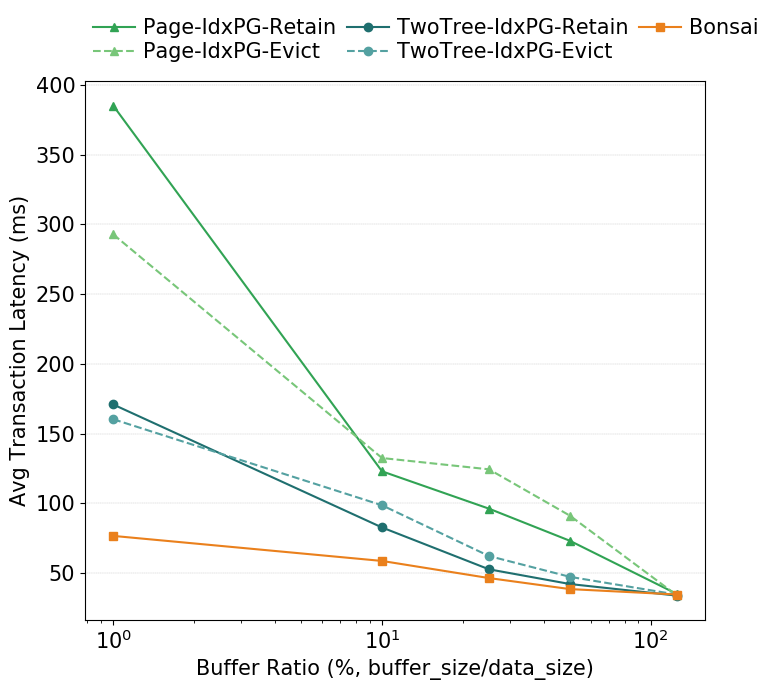

In [3]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(1, 1, 1)




# ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
#         df_tuple["txn_latency_perc99_us"]/1000,
#         # df_tuple["avg_sum_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai", linestyle='dashed')


ax.plot(df_page["g_total_buf_sz"]*100/(12*1000*1000*1000), 
    # df_tuple["txn_latency_perc99_us"]/1000,
        df_page["avg_sum_txn_latency (us)"]/1000,
        color=page_retain_c,
        marker="^", label="Page-IdxPG-Retain")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
    # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        df_page_idx_evict["avg_sum_txn_latency (us)"]/1000,
        color=page_evict_c,
        marker="^", label="Page-IdxPG-Evict", linestyle='dashed')
# # print(df_page["throughput_txn_per_sec"])
# # # Annotate each data point with its corresponding value
# # for i in range(len(df_page_idx_evict["g_total_buf_sz"])):
# #     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict["g_total_buf_sz"][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

#     #     ax.plot(xval, 
#     #             plot_data3.loc[y]["throughput_txn_per_sec"],
#     #             color=line_colors["ORANGE"],
#     #             marker=".", label="Remote-Index")

ax.plot(df_tt["g_total_buf_sz"]*100/(12*1000*1000*1000), 
  # df_tt["txn_latency_perc99_us"]/1000,
        df_tt["avg_sum_txn_latency (us)"]/1000,
        color=tt_retain_c,
        marker="o", label="TwoTree-IdxPG-Retain")
ax.plot(df_tt_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
  # df_tt_idx_evict["txn_latency_perc99_us"]/1000,
        df_tt_idx_evict["avg_sum_txn_latency (us)"]/1000,
        color=tt_evict_c,
        marker="o", label="TwoTree-IdxPG-Evict",  linestyle='dashed')
ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        # df_tuple["txn_latency_perc99_us"]/1000,
        df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=bonsai_c,
        marker="s", label="Bonsai")
# ax.set_ylim(0, 125)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple["g_total_buf_sz"] * 100/(12*1000*1000*1000))
ax.set_xscale('log')
# ax.set_yscale('log')
location = "upper left"
# ax.legend(loc=location, frameon=False)
ax.set_ylabel("Avg Transaction Latency (ms)")
ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax.set_title("Avg Latency Varying Buffer Size (theta 0.9, writeheavy)")
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-avg-latency.pdf",bbox_inches='tight')


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


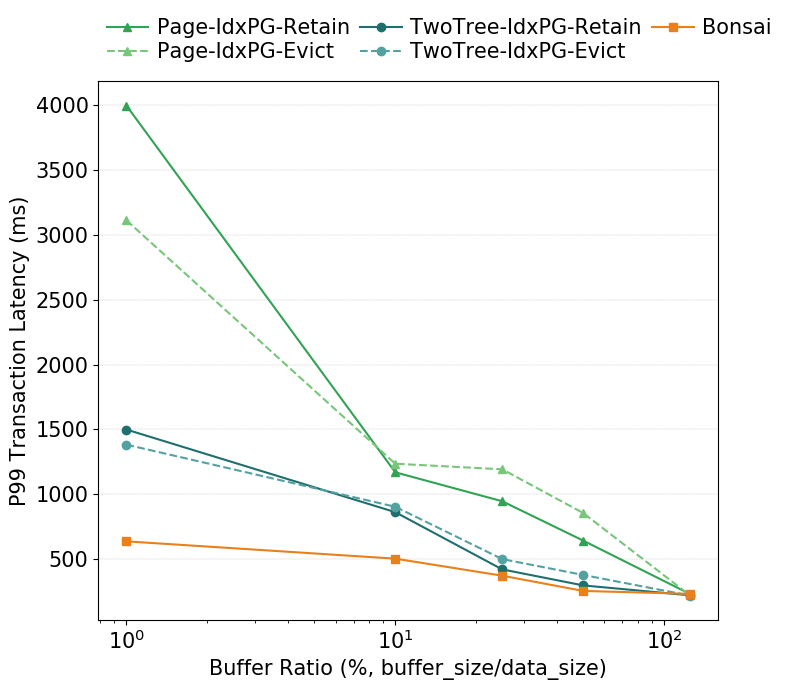

In [4]:

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(1, 1, 1)

# ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
#         # df_tuple["txn_latency_perc99_us"]/1000,
#         df_tuple["avg_sum_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai")




ax.plot(df_page["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_page["txn_latency_perc99_us"]/1000,
        color=page_retain_c,
        marker="^", label="Page-IdxPG-Retain")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_page_idx_evict["txn_latency_perc99_us"]/1000,
        color=page_evict_c,
        marker="^", label="Page-IdxPG-Evict", linestyle='dashed')
# # print(df_page["throughput_txn_per_sec"])
# # # Annotate each data point with its corresponding value
# # for i in range(len(df_page_idx_evict["g_total_buf_sz"])):
# #     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict["g_total_buf_sz"][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

#     #     ax.plot(xval, 
#     #             plot_data3.loc[y]["throughput_txn_per_sec"],
#     #             color=line_colors["ORANGE"],
#     #             marker=".", label="Remote-Index")

ax.plot(df_tt["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tt["txn_latency_perc99_us"]/1000,
        color=tt_retain_c,
        marker="o", label="TwoTree-IdxPG-Retain")
ax.plot(df_tt_idx_evict["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tt_idx_evict["txn_latency_perc99_us"]/1000,
        color=tt_evict_c,
        marker="o", label="TwoTree-IdxPG-Evict",  linestyle='dashed')
ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_tuple["txn_latency_perc99_us"]/1000,
        # df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=bonsai_c,
        marker="s", label="Bonsai")
# ax.set_ylim(0, 700)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple["g_total_buf_sz"] * 100/(12*1000*1000*1000))
ax.set_xscale('log')
# ax.set_yscale('log')
location = "upper left"
# ax.legend(loc=location, frameon=False)
ax.set_ylabel("P99 Transaction Latency (ms)")
ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax.set_title("P99 Latency Varying Buffer Size (theta 0.9, writeheavy)")
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-p99-latency.pdf",bbox_inches='tight')



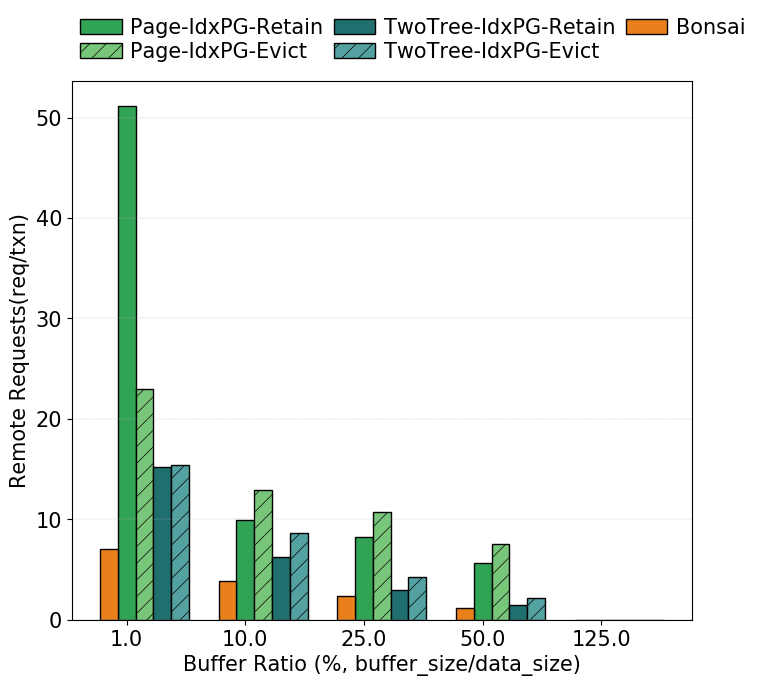

In [5]:


fig = plt.figure(figsize=(8, 7))


index = np.arange(len(df_tuple["g_total_buf_sz"]))

bar_width = 0.15

# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(1, 1, 1)




ax1.bar(index + 2 * bar_width, 
        df_page["misses_"]/df_page["txn_cnt_"], bar_width, edgecolor='black',
        color=page_retain_c,
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        df_page_idx_evict["misses_"]/df_page_idx_evict["txn_cnt_"], bar_width,edgecolor='black',
        color=page_evict_c,
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        df_tt["misses_"]/df_tt["txn_cnt_"], bar_width,edgecolor='black',
        color=tt_retain_c,
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        df_tt_idx_evict["misses_"]/df_tt_idx_evict["txn_cnt_"],bar_width,edgecolor='black',
        color=tt_evict_c,
        label="TwoTree-IdxPG-Evict",hatch="//")
ax1.bar(index + 1 * bar_width, 
        df_tuple["misses_"]/df_tuple["txn_cnt_"] , bar_width,edgecolor='black',
        color=bonsai_c,
        label="Bonsai")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
# ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Remote Requests(req/txn)")
ax1.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax1.set_xscale('log')
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)

legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-analysis-remote-reqs-num.pdf",bbox_inches='tight')

# ax1.set_title("Remote Requests Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
# fig1.set_size_inches(8, 6)
# fig.set_size_inches(8, 6)



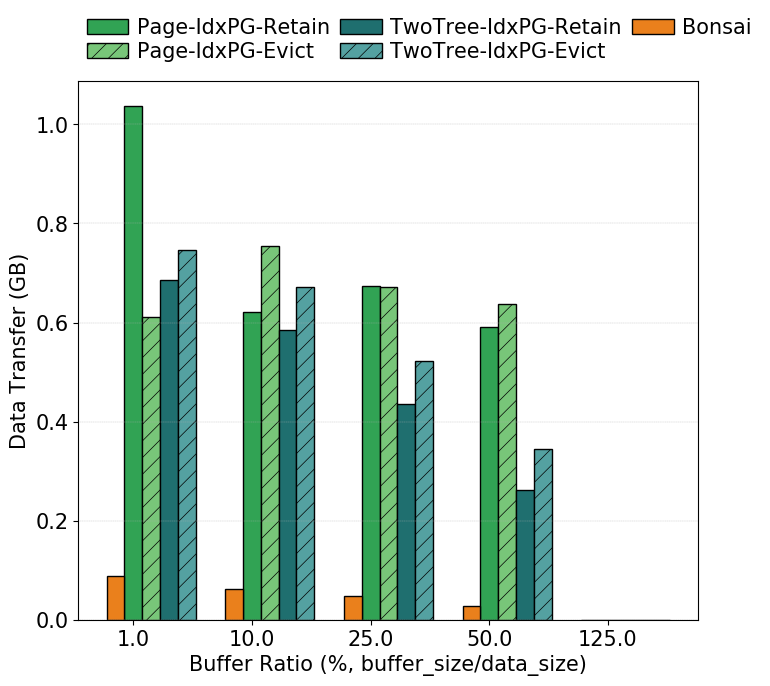

In [6]:
fig = plt.figure(figsize=(8, 7))

ax1 = fig.add_subplot(1, 1, 1)



ax1.bar(index + 2 * bar_width, 
        (df_page["misses_"])*8/1000000.0, bar_width, edgecolor='black',
        color=page_retain_c,
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        (df_page_idx_evict["misses_"])*8/1000000.0, bar_width,edgecolor='black',
        color=page_evict_c,
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        (df_tt["misses_"])*8/1000000.0, bar_width,edgecolor='black',
        color=tt_retain_c,
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        (df_tt_idx_evict["misses_"])*8/1000000.0,bar_width,edgecolor='black',
        color=tt_evict_c,
        label="TwoTree-IdxPG-Evict",hatch="//")
ax1.bar(index + 1 * bar_width, 
        df_tuple["misses_"]/1000000.0, bar_width,edgecolor='black',
        color=bonsai_c,
        label="Bonsai")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Data Transfer (GB)")
ax1.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax1.set_yscale('log')

# ax1.set_xscale('log')
# ax1.set_title("Data Transfer Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-analysis-data-transfer.pdf",bbox_inches='tight')


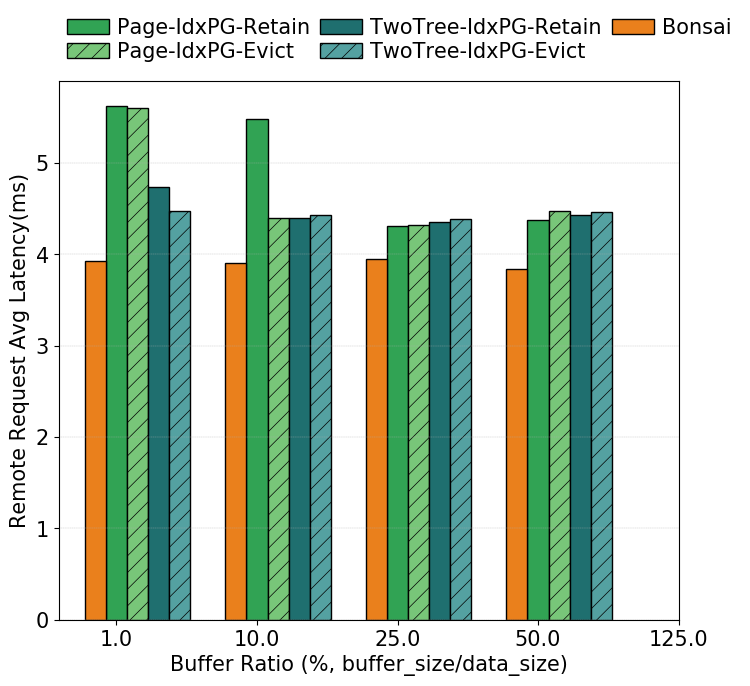

In [8]:

fig = plt.figure(figsize=(8, 7))

ax1 = fig.add_subplot(1, 1, 1)



ax1.bar(index + 2 * bar_width, 
        (df_page["remote_io_time_ms"])*1.0/df_page["remote_rds_"], bar_width, edgecolor='black',
        color=page_retain_c,
        label="Page-IdxPG-Retain")
ax1.bar(index[:-1] + 3 * bar_width, 
        # (df_page_idx_evict["misses_"])*8/1000000.0, bar_width,edgecolor='black',
        ((df_page_idx_evict["remote_io_time_ms"])*1.0/df_page_idx_evict["remote_rds_"])[:-1], bar_width,edgecolor='black',
        color=page_evict_c,
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        # (df_tt["misses_"])*8/1000000.0, bar_width,edgecolor='black',
         (df_tt["remote_io_time_ms"])*1.0/df_tt["remote_rds_"], bar_width,edgecolor='black',
        color=tt_retain_c,
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        # (df_tt_idx_evict["misses_"])*8/1000000.0,bar_width,edgecolor='black',
        ((df_tt_idx_evict["remote_io_time_ms"])*1.0/df_tt_idx_evict["remote_rds_"]),bar_width,edgecolor='black',
        color=tt_evict_c,
        label="TwoTree-IdxPG-Evict",hatch="//")
ax1.bar(index + 1 * bar_width, 
        df_tuple["remote_io_time_ms"]*1.0/df_tuple["remote_rds_"], bar_width,edgecolor='black',
        color=bonsai_c,
        label="Bonsai")
plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
# ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Remote Request Avg Latency(ms)")
ax1.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax1.set_yscale('log')

# ax1.set_xscale('log')
# ax1.set_title("Remote Request Avg Latency Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-analysis-remote-reqs-latency.pdf",bbox_inches='tight')


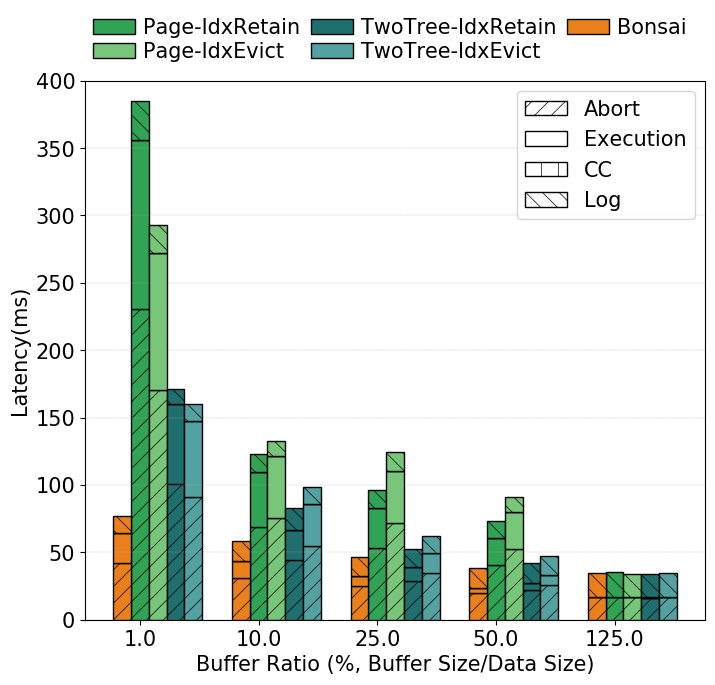

In [10]:
from matplotlib.patches import Patch
fig = plt.figure(figsize=(8, 7))

ax1 = fig.add_subplot(1, 1, 1)
index = np.arange(len(df_tuple["g_total_buf_sz"]))

cur_label="Page"
cur_color=page_retain_c
cur_df = df_page 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 2
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='//',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='|',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

cur_label="Page"
cur_color=page_evict_c
cur_df = df_page_idx_evict 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 3
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='//',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='|',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

cur_label="TwoTree"
cur_color=tt_retain_c
cur_df = df_tt 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 4
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='//',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='|',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")


cur_label="TwoTree"
cur_color=tt_evict_c
cur_df = df_tt_idx_evict
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 5
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='//',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='|',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

cur_label="Bonsai"
cur_color=bonsai_c
cur_df = df_tuple 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 1
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='//',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='|',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
# ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Latency(ms)")
# ax1.set_xlabel("Zipf Theta")
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax1.set_xlabel("Buffer Ratio (%, Buffer Size/Data Size)")

subcategories = ['Abort', 'Execution', 'CC', 'Log']  # Stacks within each bar
bar_labels = [ 'Page-IdxRetain', 'Page-IdxEvict', 'TwoTree-IdxRetain', 'TwoTree-IdxEvict', 'Bonsai']  # Bars within each group


# Colors for the bars (categories)
colors = [page_retain_c, page_evict_c, tt_retain_c, tt_evict_c,bonsai_c]

# Hatches for the subcategories
hatches = ['//', '', '|', '\\\\']

# Create custom patches for the subcategories
hatch_patches = [Patch(facecolor='white', edgecolor='black', hatch=h, label=sc)
                 for h, sc in zip(hatches, subcategories)]

# Create custom patches for the categories
color_patches = [Patch(facecolor=c, edgecolor='black', label=bl)
                 for c, bl in zip(colors, bar_labels)]
ax1.set_ylim(0, 400)

# Create legends
subcat_legend = plt.legend(handles=hatch_patches, loc='best')
ax1.add_artist(subcat_legend)  # Add the first legend manually to keep it when adding the second
plt.legend(handles=color_patches, bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)

# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
#            ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-analysis-latency-breakdown.pdf",bbox_inches='tight')
